# Notebook Pengujian
## Tugas Besar 1 IF3270 Pembelajaran Mesin

**Anggota**
- 13523070 - Sebastian Hung Yansen
- 13523082 - Aramazaya

## 0. Import Libraries and Load Data

In [1]:
# 0. Import Libraries and Load Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score
from importlib import reload
import ffnn

# Load Dataset
train_df = pd.read_csv("dataset/datasetml_2026.csv")
print("Dataset shape:", train_df.shape)
train_df.head()

Dataset shape: (10000, 12)


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


## 1. Exploratory Data Analysis (EDA)

### 1.1. Gambaran Umum Dataset

In [2]:
train_df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 937.6+ KB


### 1.2. Statistik Deskriptif

In [4]:
train_df.describe(include='all')

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
count,10000.000000,10000.000000,10000,10000,10000,10000.00000,10000.000000,10000.000000,10000,10000,10000.000000,10000
unique,NaN,NaN,3,5,3,NaN,NaN,NaN,5,6,NaN,2
top,NaN,NaN,Tier 2,Germany,300+,NaN,NaN,NaN,Data Science,Consulting,NaN,Placed
freq,NaN,NaN,3993,2057,4075,NaN,NaN,NaN,2036,1739,NaN,6153
mean,6.998290,1.248100,NaN,NaN,NaN,1.49930,69.877531,65.158600,NaN,NaN,5.021436,NaN
std,0.802606,1.149904,NaN,NaN,NaN,1.20289,14.700532,14.740446,NaN,NaN,1.505975,NaN
min,4.000000,0.000000,NaN,NaN,NaN,0.00000,30.000000,30.000000,NaN,NaN,1.000000,NaN
25%,6.461928,0.000000,NaN,NaN,NaN,1.00000,59.880399,55.112244,NaN,NaN,4.012656,NaN
50%,6.997924,1.000000,NaN,NaN,NaN,1.00000,70.097368,65.006484,NaN,NaN,5.017335,NaN
75%,7.536865,2.000000,NaN,NaN,NaN,2.00000,80.213934,75.277248,NaN,NaN,6.031400,NaN


### 1.3. Distribusi Kelas Target

In [5]:
print(train_df['placement_status'].value_counts())
print(train_df['placement_status'].value_counts(normalize=True).round(3))

placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64
placement_status
Placed        0.615
Not Placed    0.385
Name: proportion, dtype: float64


### 1.4. Distribusi Fitur Numerik

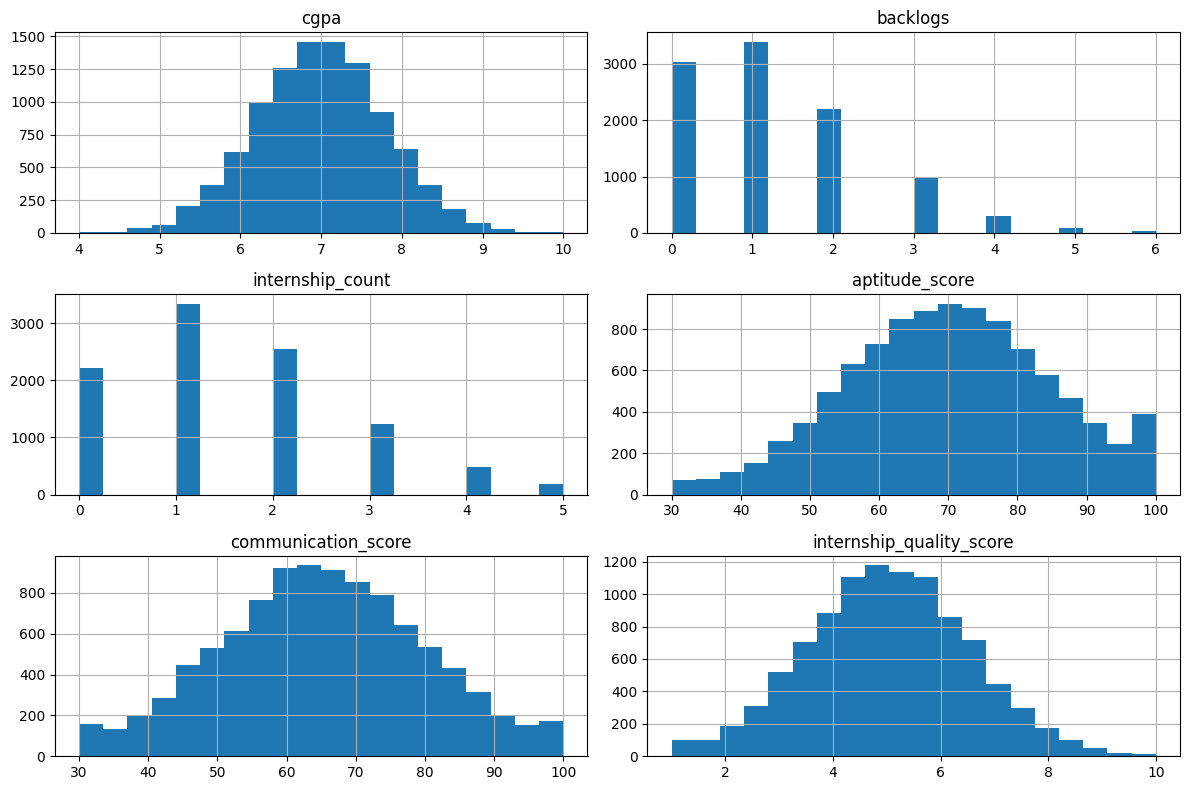

In [6]:
numeric_cols = ["cgpa", "backlogs", "internship_count",
                "aptitude_score", "communication_score",
                "internship_quality_score"]

train_df[numeric_cols].hist(bins=20, figsize=(12, 8)) # histogram
plt.tight_layout()
plt.show()

### 1.5. Distribusi Fitur Kategorikal

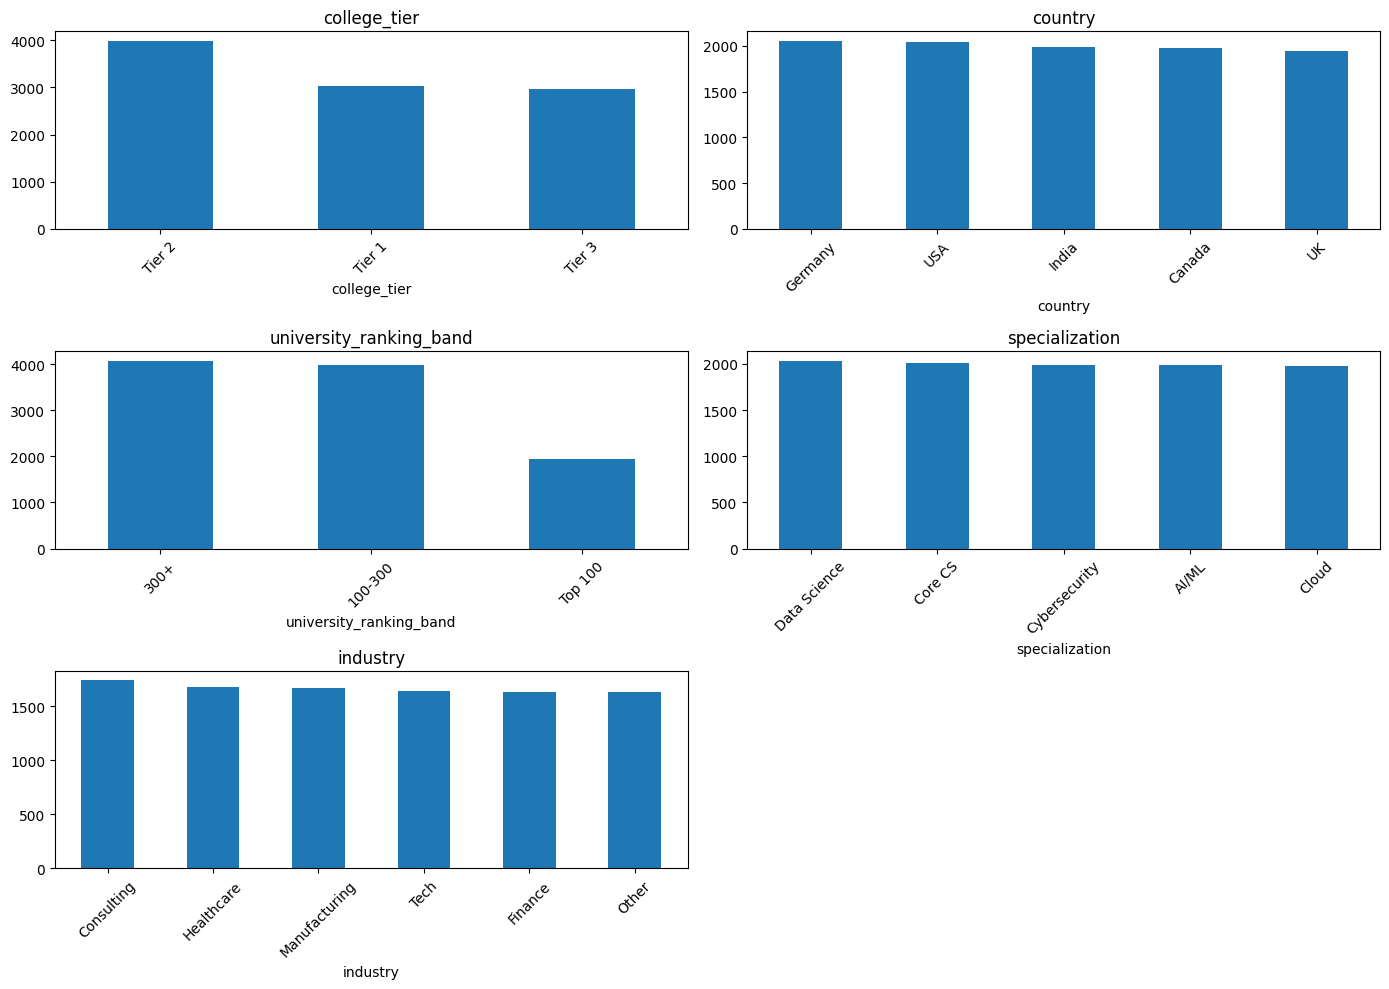

In [7]:
cat_cols = ["college_tier", "country",
            "university_ranking_band",
            "specialization", "industry"]

plt.figure(figsize=(14, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 2, i) # barplot
    train_df[col].value_counts().plot(kind="bar")
    plt.title(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Data Preprocessing

In [8]:
df = train_df.copy()

# Target: mapping ke 0/1
y_raw = df["placement_status"].map({"Placed": 1, "Not Placed": 0}).values

# Fitur
X_raw = df.drop(columns=["placement_status"])

cat_cols = X_raw.select_dtypes(include=["object"]).columns
num_cols = X_raw.select_dtypes(exclude=["object"]).columns

print("Categorical columns:", list(cat_cols))
print("Numeric columns:", list(num_cols))

Categorical columns: ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']
Numeric columns: ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']


C:\Users\Sandra\AppData\Local\Temp\ipykernel_54076\2016672450.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_raw.select_dtypes(include=["object"]).columns


### One-Hot Encoding untuk fitur kategorikal

In [9]:
enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_cat = enc.fit_transform(X_raw[cat_cols])
X_num = X_raw[num_cols].values

X = np.concatenate([X_num, X_cat], axis=1)
y = y_raw

print("Final feature shape:", X.shape)

Final feature shape: (10000, 28)


In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_raw[num_cols].values)
X = np.concatenate([X_num_scaled, X_cat], axis=1)

## Train/Validation Split

In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape, "X_val:", X_val.shape)
print("y_train positive ratio:", y_train.mean().round(3))
print("y_val positive ratio:", y_val.mean().round(3))

X_train: (8000, 28) X_val: (2000, 28)
y_train positive ratio: 0.615
y_val positive ratio: 0.616


## 3. Wrapper / Helper untuk FFNN

In [ ]:
from importlib import reload
import ffnn
reload(ffnn)
from ffnn import FeedForwardNN

def train_ffnn_config(
    layer_sizes=[X_train.shape[1], 4, 4, 2],
    activations=['linear', 'tanh', 'leaky_relu', 'sigmoid'],
    loss_function="binary_cross_entropy",
    learning_rate=0.01,
    epochs=20,
    batch_size=1,
    weight_init="normal",
    weight_variance=0.01,
    verbose=True,
    l1 = 0.0,
    l2 = 0.0
):
    model = FeedForwardNN(
        neurons=layer_sizes,
        activation_function=activations,
        loss_function=loss_function,
        learning_rate=learning_rate,
        loss_threshold=0.01,
        epochs=epochs,
        weight_init=weight_init,
        weight_variance=weight_variance,
        batch_size=batch_size,
        l1 = l1,
        l2 = l2,
        verbose=verbose
    )

    history = model.fit(X_train, y_train, X_val=X_val, y_val=y_val)

    # Predictions on validation set
    y_val_pred_raw = model.predict(X_val)

    # If model outputs probabilities (continuous), convert to class labels
    # Handle both shape (n_samples,) and (n_samples, 1)
    import numpy as np
    if isinstance(y_val_pred_raw, np.ndarray) and y_val_pred_raw.dtype != int:
        if y_val_pred_raw.ndim == 1:
            y_val_pred = (y_val_pred_raw >= 0.5).astype(int)
        elif y_val_pred_raw.ndim == 2 and y_val_pred_raw.shape[1] == 1:
            y_val_pred = (y_val_pred_raw[:, 0] >= 0.5).astype(int)
        else:
            y_val_pred = np.argmax(y_val_pred_raw, axis=1)
    else:
        y_val_pred = y_val_pred_raw

    from sklearn.metrics import accuracy_score
    acc = accuracy_score(y_val, y_val_pred)

    return model, y_val_pred_raw, y_val_pred, acc, history

## 4. Eksperimen Hyperparameter

In [14]:
configs_depth_width = [
    # Width variation (depth tetap: 2 hidden layer)
    {"name": "width_small",  "layer_sizes": [X_train.shape[1], 2, 2, 2]},
    {"name": "width_medium", "layer_sizes": [X_train.shape[1], 4, 4, 2]},
    {"name": "width_large",  "layer_sizes": [X_train.shape[1], 8, 8, 2]},
    # Depth variation (width tetap: 32 neuron)
    {"name": "depth_1", "layer_sizes": [X_train.shape[1], 4, 2]},
    {"name": "depth_2", "layer_sizes": [X_train.shape[1], 4, 4, 2]},
    {"name": "depth_3", "layer_sizes": [X_train.shape[1], 4, 4, 4, 2]},
]

results_depth_width = []

for cfg in configs_depth_width:
    print(f"Training config: {cfg['name']}, layers={cfg['layer_sizes']}")
    model, y_val_pred_raw, y_val_pred, acc, _ = train_ffnn_config(
        layer_sizes=cfg["layer_sizes"],
        epochs=20
    )
    results_depth_width.append(
        {"name": cfg["name"], "layer_sizes": cfg["layer_sizes"],
         "model": model, "y_val_pred_raw": y_val_pred_raw,
         "y_val_pred": y_val_pred, "acc": acc, "history": _}
    )
    print(f"  Validation accuracy: {acc:.4f}")

Training config: width_small, layers=[28, 2, 2, 2]
I AM SPEED
Epoch 1/20, Loss: 1.335532, Val Loss: 1.334739
Epoch 2/20, Loss: 1.333788, Val Loss: 1.334739
Epoch 3/20, Loss: 1.333788, Val Loss: 1.334739
Epoch 4/20, Loss: 1.333787, Val Loss: 1.334739
Epoch 5/20, Loss: 1.333787, Val Loss: 1.334738
Epoch 6/20, Loss: 1.333783, Val Loss: 1.334728
Epoch 7/20, Loss: 1.323148, Val Loss: 1.094142
Epoch 8/20, Loss: 1.010696, Val Loss: 1.026662
Epoch 9/20, Loss: 0.998616, Val Loss: 1.025083
Epoch 10/20, Loss: 0.996702, Val Loss: 1.024412
Epoch 11/20, Loss: 0.992279, Val Loss: 1.020073
Epoch 12/20, Loss: 0.988418, Val Loss: 1.020148
Epoch 13/20, Loss: 0.987445, Val Loss: 1.021981
Epoch 14/20, Loss: 0.987238, Val Loss: 1.023339
Epoch 15/20, Loss: 0.987111, Val Loss: 1.024437
Epoch 16/20, Loss: 0.986990, Val Loss: 1.025377
Epoch 17/20, Loss: 0.986886, Val Loss: 1.026078
Epoch 18/20, Loss: 0.986768, Val Loss: 1.026590
Epoch 19/20, Loss: 0.986629, Val Loss: 1.026988
Epoch 20/20, Loss: 0.986477, Val Lo

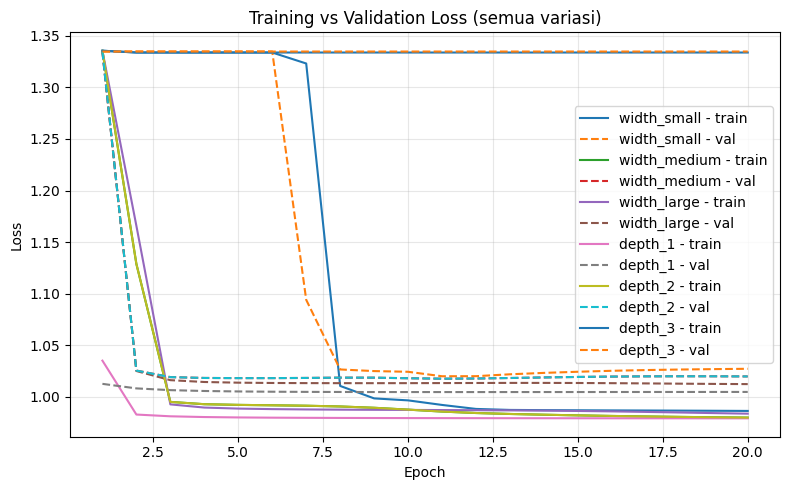

In [15]:
plt.figure(figsize=(8, 5))
for res in results_depth_width:
    hist = res["history"]
    epochs_range = range(1, len(hist["train_loss"]) + 1)
    plt.plot(epochs_range, hist["train_loss"], label=f"{res['name']} - train")
    if hist["val_loss"]:
        plt.plot(epochs_range, hist["val_loss"], linestyle="--", label=f"{res['name']} - val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (semua variasi)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

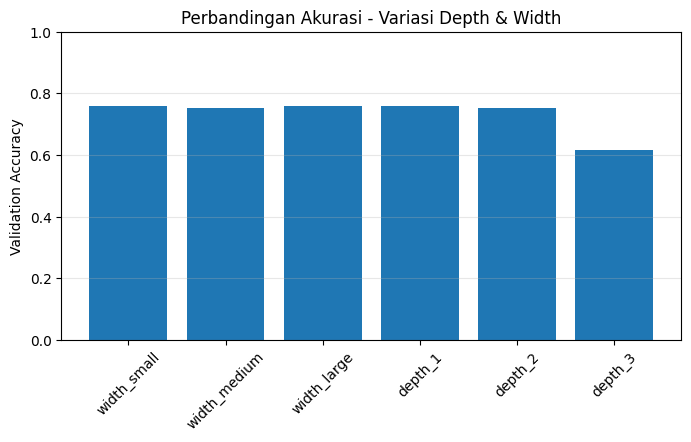

In [16]:
# Plot akurasi untuk setiap konfigurasi depth/width

names = [r["name"] for r in results_depth_width]
accs = [r["acc"] for r in results_depth_width]

plt.figure(figsize=(8, 4))
plt.bar(names, accs)
plt.xticks(rotation=45)
plt.ylabel("Validation Accuracy")
plt.title("Perbandingan Akurasi - Variasi Depth & Width")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [ ]:
def plot_weight_gradient_dist(results, label_fn, title):
    n_layers = len(results[0]["model"].get_weights())
    fig, axes = plt.subplots(2, n_layers, figsize=(5 * n_layers, 8))
    if n_layers == 1:
        axes = axes.reshape(2, 1)
    for res in results:
        label = label_fn(res)
        layers = res["model"].compute_gradients(X_val, y_val)
        for l_idx, layer in enumerate(layers):
            w_flat = layer["weights"].flatten()
            g_flat = layer["weight_gradients"].flatten()
            axes[0, l_idx].hist(w_flat, bins=30, alpha=0.5, label=label, density=True)
            axes[1, l_idx].hist(g_flat, bins=30, alpha=0.5, label=label, density=True)
    for l_idx in range(n_layers):
        axes[0, l_idx].set_title(f"Layer {l_idx} - Weight Distribution")
        axes[0, l_idx].set_xlabel("Weight value")
        axes[0, l_idx].set_ylabel("Density")
        axes[0, l_idx].legend()
        axes[0, l_idx].grid(True, alpha=0.3)
        axes[1, l_idx].set_title(f"Layer {l_idx} - Gradient Distribution")
        axes[1, l_idx].set_xlabel("Gradient value")
        axes[1, l_idx].set_ylabel("Density")
        axes[1, l_idx].legend()
        axes[1, l_idx].grid(True, alpha=0.3)
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

## 5. Eksperimen Fungsi Aktivasi Hidden Layer

In [13]:
test_layer_index = 1

activation_candidates = ["relu", "sigmoid", "tanh", "linear", "leaky_relu", "elu"]
results_activation = []

for act in activation_candidates:
    hidden_acts = ["relu", "relu"]
    hidden_acts[test_layer_index - 1] = act
    activations = hidden_acts + ["sigmoid"]

    print(f"Training dengan activation {activations} pada hidden layer ke-{test_layer_index}")
    model, y_val_pred_raw, y_val_pred, acc, _ = train_ffnn_config(
        activations=activations,
    )
    results_activation.append(
        {"activation": act, "model": model,
         "y_val_pred_raw": y_val_pred_raw,
         "y_val_pred": y_val_pred, "acc": acc, "history": _}
    )
    print(f"  Validation accuracy: {acc:.4f}")

Training dengan activation ['relu', 'relu', 'sigmoid'] pada hidden layer ke-1
Epoch 1/20, Loss: 1.335479, Val Loss: 1.334739
Epoch 2/20, Loss: 1.333771, Val Loss: 1.334686
Epoch 3/20, Loss: 1.235037, Val Loss: 1.036692
Epoch 4/20, Loss: 0.997494, Val Loss: 1.024067
Epoch 5/20, Loss: 0.989340, Val Loss: 1.022241
Epoch 6/20, Loss: 0.987025, Val Loss: 1.021393
Epoch 7/20, Loss: 0.986071, Val Loss: 1.019042
Epoch 8/20, Loss: 0.984760, Val Loss: 1.021698
Epoch 9/20, Loss: 0.984349, Val Loss: 1.021876
Epoch 10/20, Loss: 0.983154, Val Loss: 1.021015
Epoch 11/20, Loss: 0.982781, Val Loss: 1.019911
Epoch 12/20, Loss: 0.981799, Val Loss: 1.021133
Epoch 13/20, Loss: 0.981477, Val Loss: 1.022361
Epoch 14/20, Loss: 0.980422, Val Loss: 1.025731
Epoch 15/20, Loss: 0.979765, Val Loss: 1.021806
Epoch 16/20, Loss: 0.979639, Val Loss: 1.022849
Epoch 17/20, Loss: 0.979126, Val Loss: 1.021991
Epoch 18/20, Loss: 0.978775, Val Loss: 1.021021
Epoch 19/20, Loss: 0.978550, Val Loss: 1.023532
Epoch 20/20, Loss: 

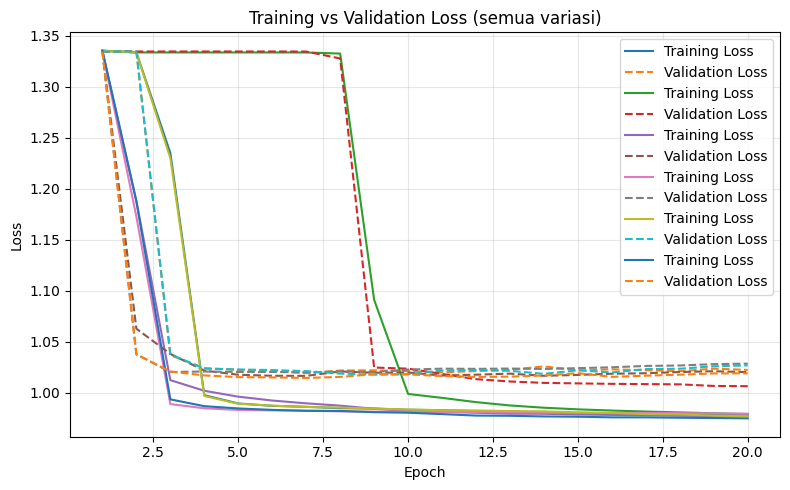

In [14]:
plt.figure(figsize=(8, 5))
for res in results_activation:
    hist = res["history"]
    epochs_range = range(1, len(hist["train_loss"]) + 1)
    plt.plot(epochs_range, hist["train_loss"], label=f"Training Loss")
    if hist["val_loss"]:
        plt.plot(epochs_range, hist["val_loss"], linestyle="--", label=f"Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (semua variasi)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

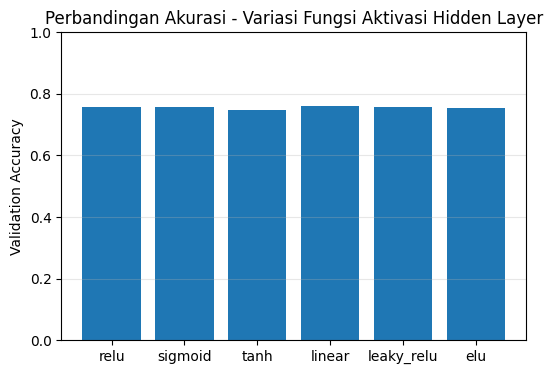

In [15]:
# Plot akurasi untuk variasi fungsi aktivasi

names = [r["activation"] for r in results_activation]
accs = [r["acc"] for r in results_activation]

plt.figure(figsize=(6, 4))
plt.bar(names, accs)
plt.ylabel("Validation Accuracy")
plt.title("Perbandingan Akurasi - Variasi Fungsi Aktivasi Hidden Layer")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()

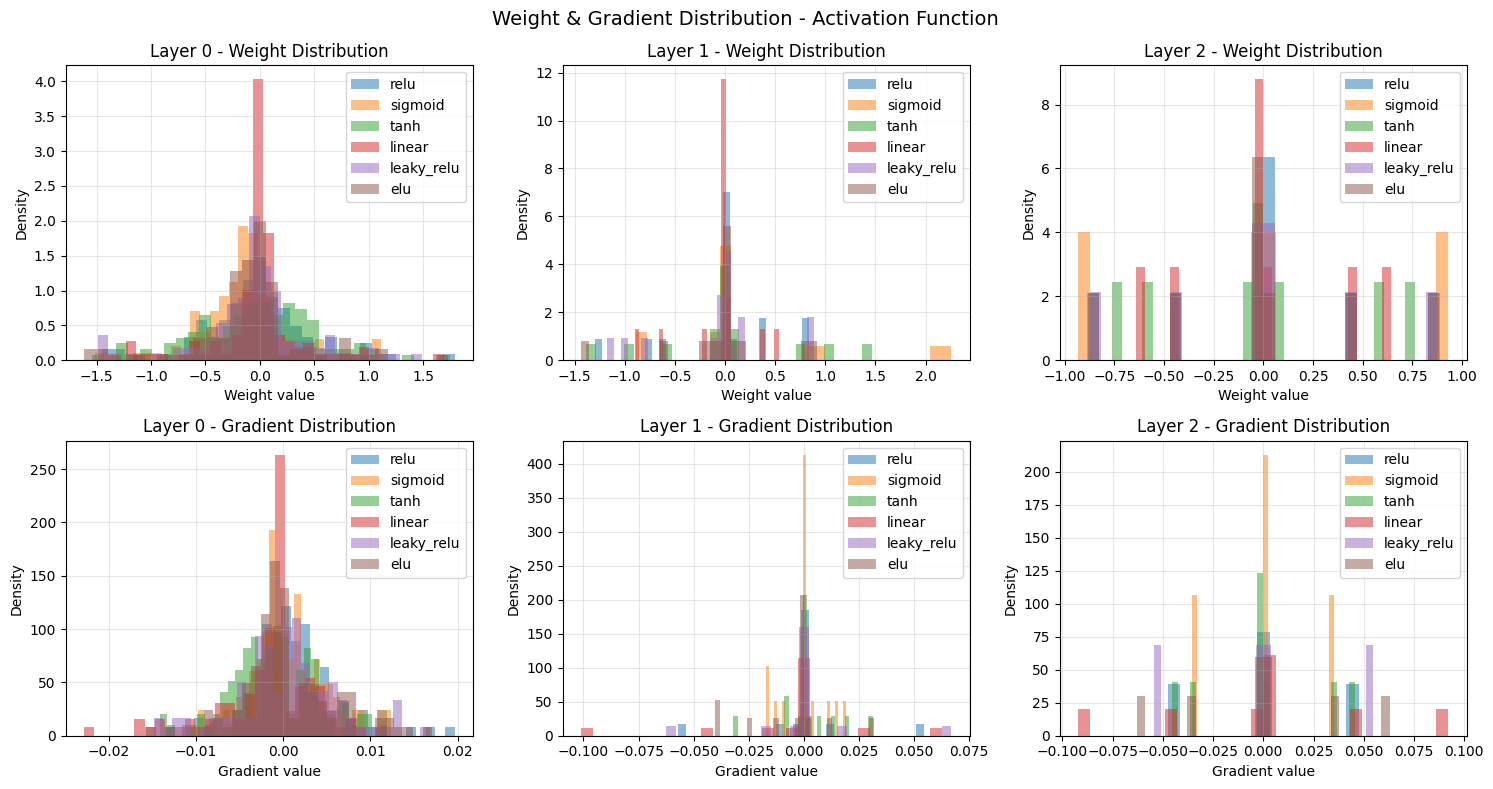

In [18]:
plot_weight_gradient_dist(
    results_activation,
    label_fn=lambda r: r["activation"],
    title="Weight & Gradient Distribution - Activation Function"
)

## 6. Eksperimen Learning Rate

In [19]:
learning_rates = [0.001, 0.01, 0.1]
results_lr = []

for lr in learning_rates:
    print(f"Training dengan learning rate = {lr}")
    model, y_val_pred_raw, y_val_pred, acc, _ = train_ffnn_config(
        learning_rate = lr
    )
    results_lr.append(
        {"lr": lr, "model": model,
         "y_val_pred_raw": y_val_pred_raw,
         "y_val_pred": y_val_pred, "acc": acc, "history": _}
    )
    print(f"  Validation accuracy: {acc:.4f}")

Training dengan learning rate = 0.001
Epoch 1/20, Loss: 1.346392, Val Loss: 1.333380
Epoch 2/20, Loss: 1.333119, Val Loss: 1.332447
Epoch 3/20, Loss: 1.332847, Val Loss: 1.332444
Epoch 4/20, Loss: 1.332839, Val Loss: 1.332443
Epoch 5/20, Loss: 1.332835, Val Loss: 1.332438
Epoch 6/20, Loss: 1.332827, Val Loss: 1.332430
Epoch 7/20, Loss: 1.332815, Val Loss: 1.332414
Epoch 8/20, Loss: 1.332792, Val Loss: 1.332385
Epoch 9/20, Loss: 1.332747, Val Loss: 1.332322
Epoch 10/20, Loss: 1.332640, Val Loss: 1.332159
Epoch 11/20, Loss: 1.332316, Val Loss: 1.331587
Epoch 12/20, Loss: 1.330722, Val Loss: 1.327873
Epoch 13/20, Loss: 1.302759, Val Loss: 1.220281
Epoch 14/20, Loss: 1.067101, Val Loss: 1.018753
Epoch 15/20, Loss: 0.993267, Val Loss: 1.010902
Epoch 16/20, Loss: 0.985338, Val Loss: 1.009463
Epoch 17/20, Loss: 0.982808, Val Loss: 1.008937
Epoch 18/20, Loss: 0.981584, Val Loss: 1.008290
Epoch 19/20, Loss: 0.980724, Val Loss: 1.007596
Epoch 20/20, Loss: 0.980034, Val Loss: 1.006956
  Validatio

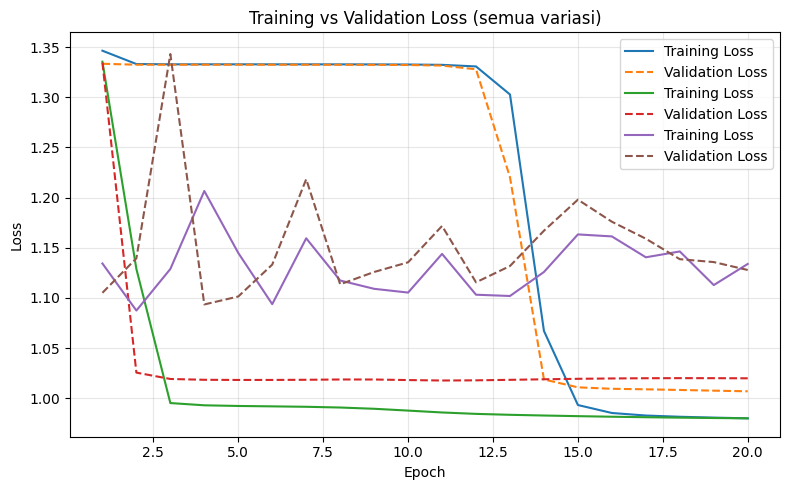

In [20]:
plt.figure(figsize=(8, 5))
for res in results_lr:
    hist = res["history"]
    epochs_range = range(1, len(hist["train_loss"]) + 1)
    plt.plot(epochs_range, hist["train_loss"], label=f"Training Loss")
    if hist["val_loss"]:
        plt.plot(epochs_range, hist["val_loss"], linestyle="--", label=f"Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (semua variasi)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

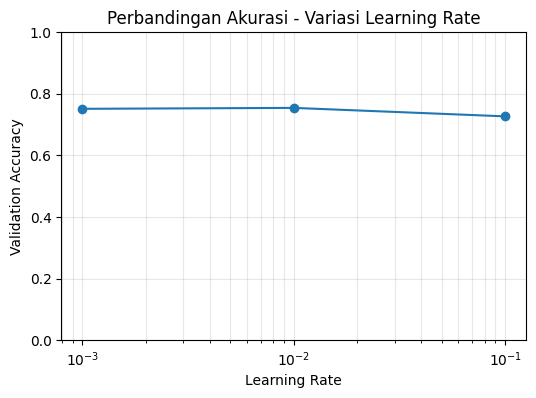

In [21]:
# Plot akurasi untuk variasi learning rate

lrs = [r["lr"] for r in results_lr]
accs = [r["acc"] for r in results_lr]

plt.figure(figsize=(6, 4))
plt.plot(lrs, accs, marker="o")
plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Validation Accuracy")
plt.title("Perbandingan Akurasi - Variasi Learning Rate")
plt.ylim(0, 1)
plt.grid(True, which="both", axis="both", alpha=0.3)
plt.show()

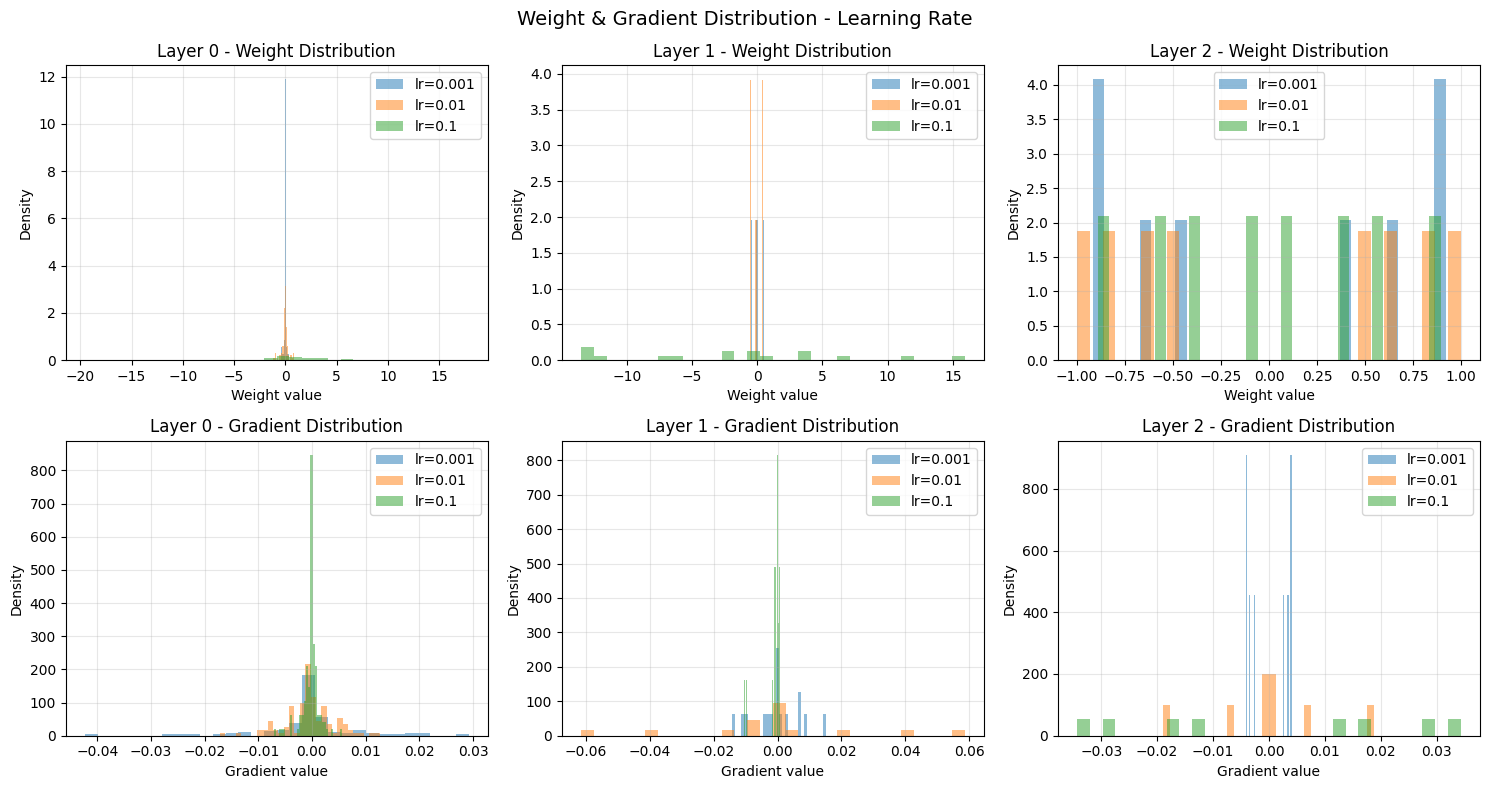

In [22]:
plot_weight_gradient_dist(
    results_lr,
    label_fn=lambda r: f"lr={r['lr']}",
    title="Weight & Gradient Distribution - Learning Rate"
)

## 7. Eksperimen Inisialisasi Bobot

In [24]:
weights = ["zeros", "random", "normal", "xavier", "he"]
results_w = []

for w in weights:
    model, y_val_pred_raw, y_val_pred, acc, _ = train_ffnn_config(
        weight_init=w,
    )
    results_w.append(
        {"w": w, "model": model,
         "y_val_pred_raw": y_val_pred_raw,
         "y_val_pred": y_val_pred, "acc": acc, "history": _}
    )
    print(f"  Validation accuracy: {acc:.4f}")

Epoch 1/20, Loss: 1.335498, Val Loss: 1.334739
Epoch 2/20, Loss: 1.333788, Val Loss: 1.334739
Epoch 3/20, Loss: 1.333788, Val Loss: 1.334739
Epoch 4/20, Loss: 1.333788, Val Loss: 1.334739
Epoch 5/20, Loss: 1.333788, Val Loss: 1.334739
Epoch 6/20, Loss: 1.333788, Val Loss: 1.334739
Epoch 7/20, Loss: 1.333788, Val Loss: 1.334739
Epoch 8/20, Loss: 1.333788, Val Loss: 1.334739
Epoch 9/20, Loss: 1.333788, Val Loss: 1.334739
Epoch 10/20, Loss: 1.333788, Val Loss: 1.334739
Epoch 11/20, Loss: 1.333788, Val Loss: 1.334739
Epoch 12/20, Loss: 1.333788, Val Loss: 1.334739
Epoch 13/20, Loss: 1.333788, Val Loss: 1.334739
Epoch 14/20, Loss: 1.333788, Val Loss: 1.334739
Epoch 15/20, Loss: 1.333788, Val Loss: 1.334739
Epoch 16/20, Loss: 1.333788, Val Loss: 1.334739
Epoch 17/20, Loss: 1.333788, Val Loss: 1.334739
Epoch 18/20, Loss: 1.333788, Val Loss: 1.334739
Epoch 19/20, Loss: 1.333788, Val Loss: 1.334739
Epoch 20/20, Loss: 1.333788, Val Loss: 1.334739
  Validation accuracy: 0.6155
Epoch 1/20, Loss: 1

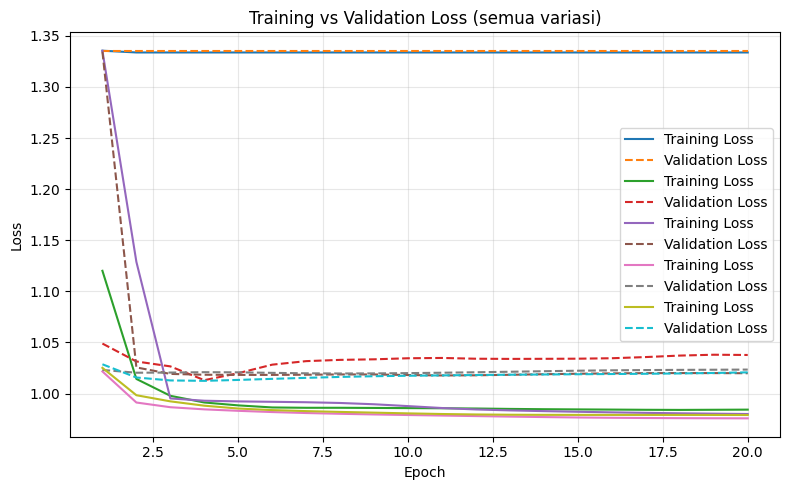

In [27]:

lrs = [r["lr"] for r in results_lr]
plt.figure(figsize=(8, 5))
for res in results_w:
    hist = res["history"]
    epochs_range = range(1, len(hist["train_loss"]) + 1)
    plt.plot(epochs_range, hist["train_loss"], label=f"Training Loss")
    if hist["val_loss"]:
        plt.plot(epochs_range, hist["val_loss"], linestyle="--", label=f"Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (semua variasi)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

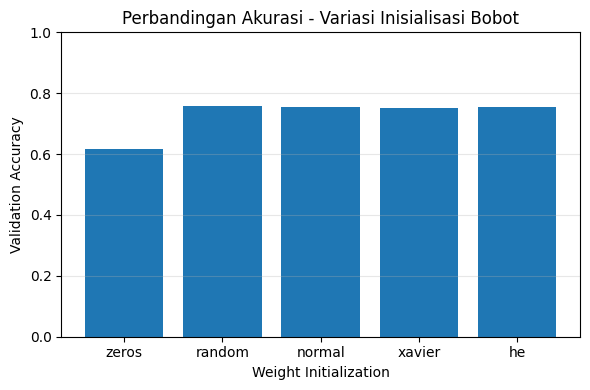

In [31]:
ws = [r["w"] for r in results_w]
accs = [r["acc"] for r in results_w]

plt.figure(figsize=(6, 4))
plt.bar(ws, accs)
plt.xlabel("Weight Initialization")
plt.ylabel("Validation Accuracy")
plt.title("Perbandingan Akurasi - Variasi Inisialisasi Bobot")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Regularisasi L1 vs L2 vs None

In [24]:
l1 = [0.0, 0.001, 0.0]
l2 = [0.0, 0.0, 0.001]
results_reg = []

for i, (l1_val, l2_val) in enumerate(zip(l1, l2)):
    model, y_val_pred_raw, y_val_pred, acc, _ = train_ffnn_config(
        l1=l1_val,
        l2=l2_val
    )
    results_reg.append(
        {"l1": l1_val, "l2": l2_val, "model": model,
         "y_val_pred_raw": y_val_pred_raw,
         "y_val_pred": y_val_pred, "acc": acc, "history": _}
    )
    print(f"  Validation accuracy: {acc:.4f}")

Epoch 1/20, Loss: 1.335446, Val Loss: 1.334557
Epoch 2/20, Loss: 1.128906, Val Loss: 1.025584
Epoch 3/20, Loss: 0.995235, Val Loss: 1.019239
Epoch 4/20, Loss: 0.993000, Val Loss: 1.018430
Epoch 5/20, Loss: 0.992337, Val Loss: 1.018266
Epoch 6/20, Loss: 0.991944, Val Loss: 1.018275
Epoch 7/20, Loss: 0.991520, Val Loss: 1.018443
Epoch 8/20, Loss: 0.990793, Val Loss: 1.018728
Epoch 9/20, Loss: 0.989534, Val Loss: 1.018712
Epoch 10/20, Loss: 0.987729, Val Loss: 1.018145
Epoch 11/20, Loss: 0.985852, Val Loss: 1.017715
Epoch 12/20, Loss: 0.984455, Val Loss: 1.017886
Epoch 13/20, Loss: 0.983529, Val Loss: 1.018383
Epoch 14/20, Loss: 0.982819, Val Loss: 1.018931
Epoch 15/20, Loss: 0.982182, Val Loss: 1.019400
Epoch 16/20, Loss: 0.981612, Val Loss: 1.019754
Epoch 17/20, Loss: 0.981119, Val Loss: 1.019979
Epoch 18/20, Loss: 0.980696, Val Loss: 1.020068
Epoch 19/20, Loss: 0.980330, Val Loss: 1.020031
Epoch 20/20, Loss: 0.980005, Val Loss: 1.019906
  Validation accuracy: 0.7540
Epoch 1/20, Loss: 1

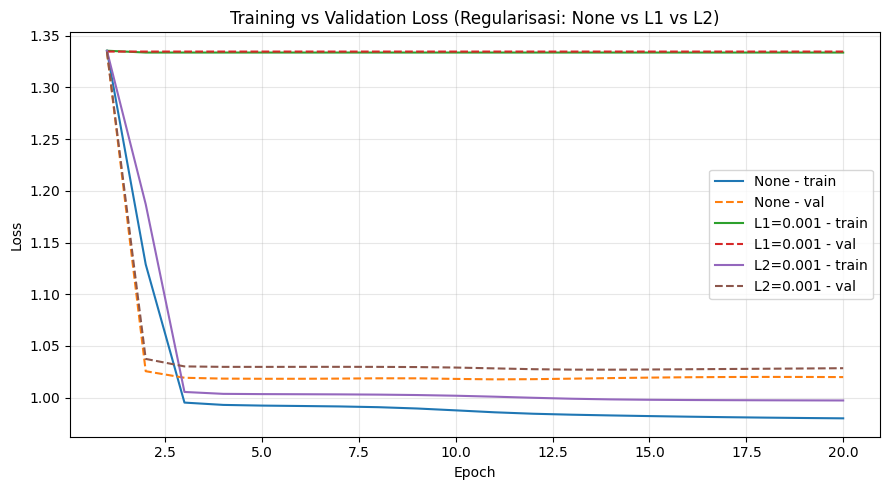

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
for res in results_reg:
    hist = res["history"]
    epochs_range = range(1, len(hist["train_loss"]) + 1)
    if res["l1"] > 0:
        name = f"L1={res['l1']}"
    elif res["l2"] > 0:
        name = f"L2={res['l2']}"
    else:
        name = "None"
    plt.plot(epochs_range, hist["train_loss"], label=f"{name} - train", linestyle="-")
    if hist["val_loss"]:
        plt.plot(epochs_range, hist["val_loss"], label=f"{name} - val", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Regularisasi: None vs L1 vs L2)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

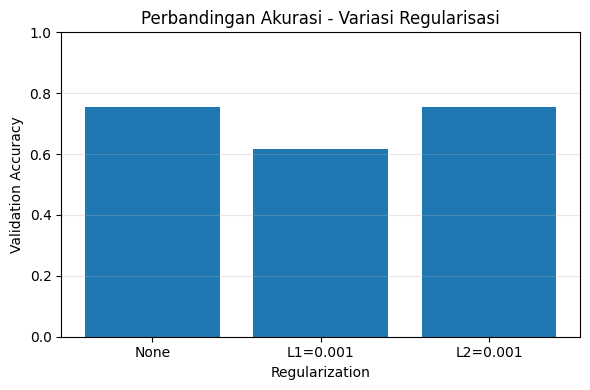

In [26]:
import matplotlib.pyplot as plt
import numpy as np

def get_reg_name(res):
    if res["l1"] > 0:
        return f"L1={res['l1']}"
    elif res["l2"] > 0:
        return f"L2={res['l2']}"
    return "None"

names = [get_reg_name(r) for r in results_reg]
accs = [r["acc"] for r in results_reg]

plt.figure(figsize=(6, 4))
plt.bar(names, accs)
plt.xlabel("Regularization")
plt.ylabel("Validation Accuracy")
plt.title("Perbandingan Akurasi - Variasi Regularisasi")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
def reg_label(r):
    if r["l1"] > 0: return f"L1={r['l1']}"
    if r["l2"] > 0: return f"L2={r['l2']}"
    return "None"

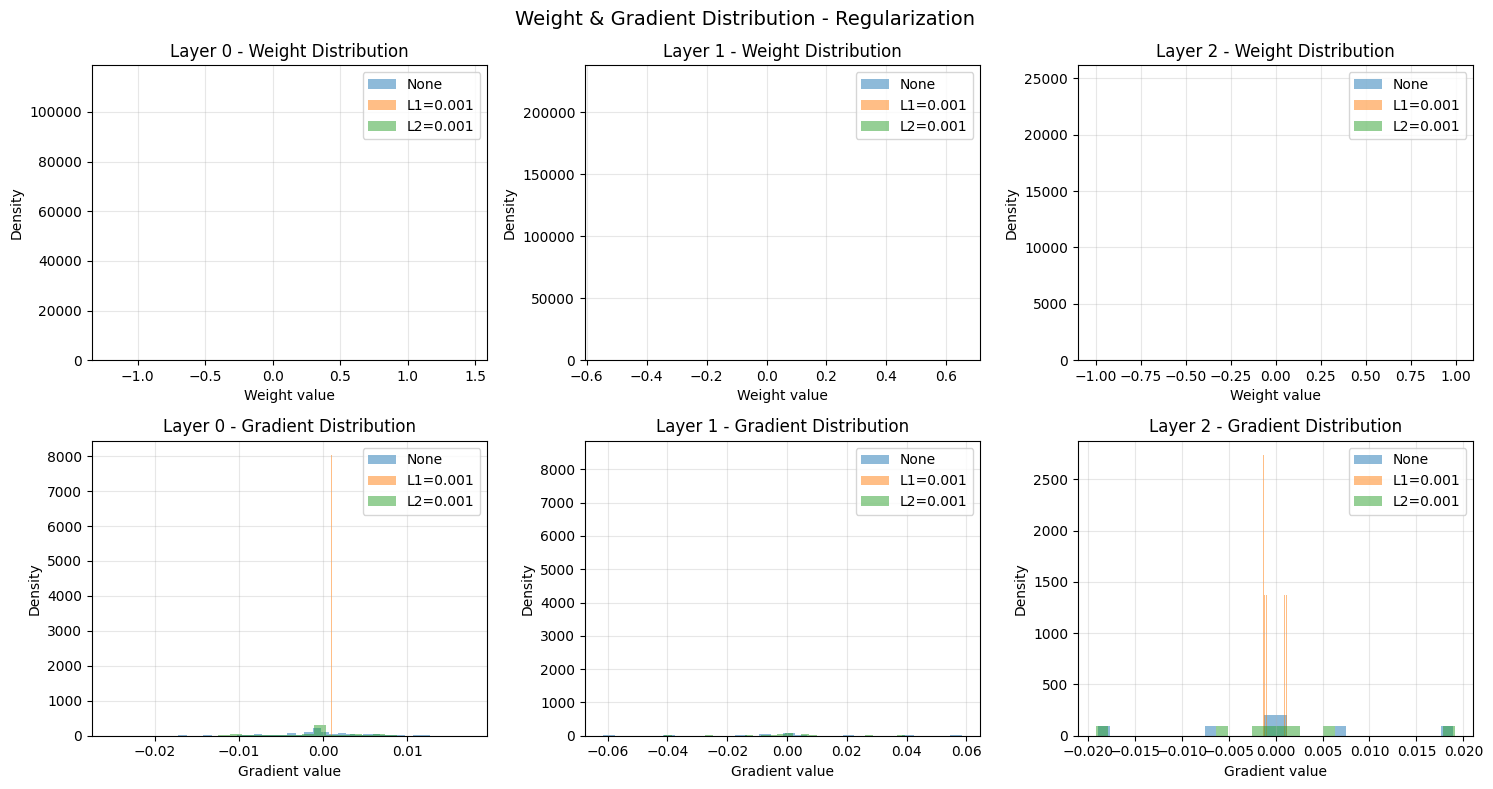

In [28]:
plot_weight_gradient_dist(
    results_reg,
    label_fn=reg_label,
    title="Weight & Gradient Distribution - Regularization"
)

## 9. Perbandingan dengan library sklearn MLP

In [37]:
from sklearn.neural_network import MLPClassifier

best_ffnn_cfg = [X_train.shape[1], 4, 4, 2]
best_ffnn_acts = ["tanh", "tanh", "softmax"]
loss = "categorical_cross_entropy"

ffnn_model, y_val_pred_raw, y_val_pred, ffnn_acc, _ = train_ffnn_config(
    layer_sizes=best_ffnn_cfg,
    activations=best_ffnn_acts,
    loss_function=loss
)

# Train sklearn MLP dengan hyperparameter yang mirip
mlp = MLPClassifier(
    hidden_layer_sizes=(4, 4),
    activation="tanh",
    learning_rate_init=0.01,
    max_iter=20,
    random_state=42,
)
mlp.fit(X_train, y_train)
y_val_pred_sklearn = mlp.predict(X_val)
mlp_acc = accuracy_score(y_val, y_val_pred_sklearn)

print(f"Akurasi FFNN (from scratch): {ffnn_acc:.4f}")
print(f"Akurasi sklearn MLP:         {mlp_acc:.4f}")

Epoch 1/20, Loss: 0.667999, Val Loss: 0.668871
Epoch 2/20, Loss: 0.578098, Val Loss: 0.519293
Epoch 3/20, Loss: 0.501896, Val Loss: 0.516300
Epoch 4/20, Loss: 0.499615, Val Loss: 0.513000
Epoch 5/20, Loss: 0.498098, Val Loss: 0.510024
Epoch 6/20, Loss: 0.496828, Val Loss: 0.507037
Epoch 7/20, Loss: 0.495369, Val Loss: 0.504521
Epoch 8/20, Loss: 0.493881, Val Loss: 0.503132
Epoch 9/20, Loss: 0.492680, Val Loss: 0.502677
Epoch 10/20, Loss: 0.491827, Val Loss: 0.502689
Epoch 11/20, Loss: 0.491220, Val Loss: 0.502873
Epoch 12/20, Loss: 0.490767, Val Loss: 0.503097
Epoch 13/20, Loss: 0.490412, Val Loss: 0.503316
Epoch 14/20, Loss: 0.490123, Val Loss: 0.503518
Epoch 15/20, Loss: 0.489877, Val Loss: 0.503707
Epoch 16/20, Loss: 0.489662, Val Loss: 0.503885
Epoch 17/20, Loss: 0.489467, Val Loss: 0.504050
Epoch 18/20, Loss: 0.489283, Val Loss: 0.504197
Epoch 19/20, Loss: 0.489103, Val Loss: 0.504316
Epoch 20/20, Loss: 0.488919, Val Loss: 0.504401
Akurasi FFNN (from scratch): 0.7570
Akurasi sklea

c:\P314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


## 10. Gradient Descent vs Adam

Training dengan Gradient Descent (SGD)...
Epoch 1/20, Loss: 0.484853, Val Loss: 0.476822
Epoch 2/20, Loss: 0.475567, Val Loss: 0.476645
Epoch 3/20, Loss: 0.432332, Val Loss: 0.342076
Epoch 4/20, Loss: 0.336365, Val Loss: 0.339361
Epoch 5/20, Loss: 0.334992, Val Loss: 0.339076
Epoch 6/20, Loss: 0.334477, Val Loss: 0.338904
Epoch 7/20, Loss: 0.334156, Val Loss: 0.338796
Epoch 8/20, Loss: 0.333938, Val Loss: 0.338724
Epoch 9/20, Loss: 0.333781, Val Loss: 0.338674
Epoch 10/20, Loss: 0.333663, Val Loss: 0.338636
Epoch 11/20, Loss: 0.333570, Val Loss: 0.338607
Epoch 12/20, Loss: 0.333495, Val Loss: 0.338585
Epoch 13/20, Loss: 0.333433, Val Loss: 0.338566
Epoch 14/20, Loss: 0.333381, Val Loss: 0.338550
Epoch 15/20, Loss: 0.333336, Val Loss: 0.338537
Epoch 16/20, Loss: 0.333297, Val Loss: 0.338525
Epoch 17/20, Loss: 0.333262, Val Loss: 0.338515
Epoch 18/20, Loss: 0.333231, Val Loss: 0.338506
Epoch 19/20, Loss: 0.333204, Val Loss: 0.338497
Epoch 20/20, Loss: 0.333179, Val Loss: 0.338490
Trainin

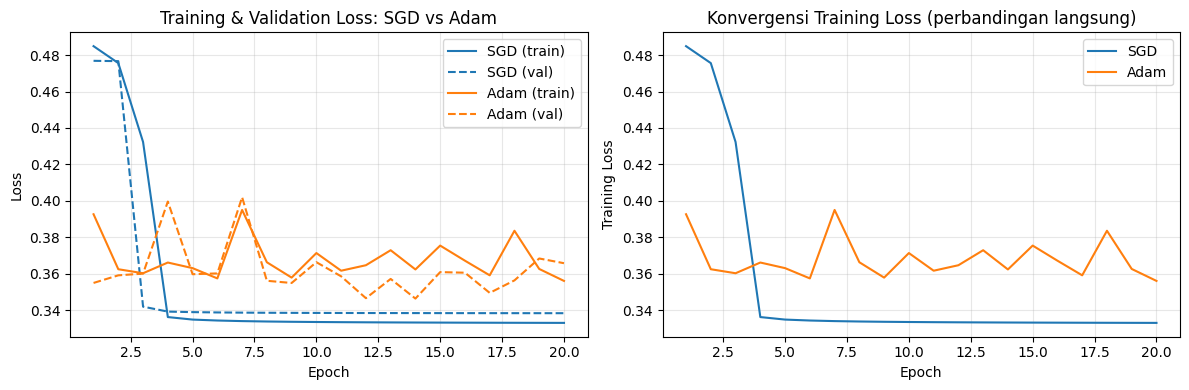


--- Ringkasan Perbandingan SGD vs Adam ---
SGD  — Waktu: 53.25s | Epochs: 20 | Final train loss: 0.333179 | Val loss: 0.338490 | Val accuracy: 0.4900
Adam — Waktu: 53.52s | Epochs: 20 | Final train loss: 0.356186 | Val loss: 0.365892 | Val accuracy: 0.2810


In [ ]:
from importlib import reload
import ffnn
reload(ffnn)
from ffnn import FeedForwardNN
import time

# --- Training dengan Gradient Descent (SGD) ---
print("Training dengan Gradient Descent (SGD)...")
t0_sgd = time.perf_counter()
model_sgd = FeedForwardNN(
    neurons=[X_train.shape[1], 4, 4, 2],
    weight_init="normal",
    weight_variance=0.01,
    epochs=20,
    optimizer="sgd"
)
history_sgd = model_sgd.fit(X_train, y_train, X_val=X_val, y_val=y_val)
time_sgd = time.perf_counter() - t0_sgd

# --- Training dengan Adam ---
print("Training dengan Adam...")
t0_adam = time.perf_counter()
model_adam = FeedForwardNN(
    neurons=[X_train.shape[1], 4, 4, 2],
    weight_init="normal",
    weight_variance=0.01,
    epochs=20,
    optimizer="adam"
)
history_adam = model_adam.fit(X_train, y_train, X_val=X_val, y_val=y_val)
time_adam = time.perf_counter() - t0_adam

# --- Prediksi & akurasi ---
y_val_pred_sgd = model_sgd.predict(X_val)
y_val_pred_adam = model_adam.predict(X_val)
# predict() untuk 2 kelas mengembalikan argmax (0/1); pastikan shape cocok dengan y_val
if y_val_pred_sgd.ndim > 1:
    y_val_pred_sgd = np.argmax(y_val_pred_sgd, axis=1)
if y_val_pred_adam.ndim > 1:
    y_val_pred_adam = np.argmax(y_val_pred_adam, axis=1)
acc_sgd = accuracy_score(y_val, y_val_pred_sgd)
acc_adam = accuracy_score(y_val, y_val_pred_adam)

# --- Plot perbandingan konvergensi ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_sgd = range(1, len(history_sgd["train_loss"]) + 1)
epochs_adam = range(1, len(history_adam["train_loss"]) + 1)

axes[0].plot(epochs_sgd, history_sgd["train_loss"], label="SGD (train)", color="C0", linestyle="-")
axes[0].plot(epochs_sgd, history_sgd["val_loss"], label="SGD (val)", color="C0", linestyle="--")
axes[0].plot(epochs_adam, history_adam["train_loss"], label="Adam (train)", color="C1", linestyle="-")
axes[0].plot(epochs_adam, history_adam["val_loss"], label="Adam (val)", color="C1", linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training & Validation Loss: SGD vs Adam")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_sgd, history_sgd["train_loss"], label="SGD", color="C0")
axes[1].plot(epochs_adam, history_adam["train_loss"], label="Adam", color="C1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Training Loss")
axes[1].set_title("Konvergensi Training Loss (perbandingan langsung)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Ringkasan analisis ---
print("\n--- Ringkasan Perbandingan SGD vs Adam ---")
print(f"SGD  — Waktu: {time_sgd:.2f}s | Epochs: {len(history_sgd['train_loss'])} | Final train loss: {history_sgd['train_loss'][-1]:.6f} | Val loss: {history_sgd['val_loss'][-1]:.6f} | Val accuracy: {acc_sgd:.4f}")
print(f"Adam — Waktu: {time_adam:.2f}s | Epochs: {len(history_adam['train_loss'])} | Final train loss: {history_adam['train_loss'][-1]:.6f} | Val loss: {history_adam['val_loss'][-1]:.6f} | Val accuracy: {acc_adam:.4f}")

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=b044e4c2-05db-4863-aa0c-338d172fe23a' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>